In [4]:
# Cell 1 - Imports and setup
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

# project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("PROJECT_ROOT:", PROJECT_ROOT)

from Sources.dataset import PDNDataset
from Sources.models import CNNAutoencoder


PROJECT_ROOT: /home/tekb/Master_Thesis_KB/CodesAndData


In [5]:
# Cell 2 - Config

EXPERIMENT_NAME = "relate_geometry_latent_space"

RUN_CFG = {
    "data_dir": "../../Data/variation",
    "csv_file": "../../Data/parameter.csv",
    "repr_name": "ln_phase",
    "latent_dim": 60,
    "batch_size": 256,

    # trained AE checkpoint
    "checkpoint_path": "../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt",

    # latent database from Phase 2
    "latent_npz_path": "../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz",
    "latent_csv_path": "../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv",
}

RESULTS_DIR = os.path.join("../../Results", EXPERIMENT_NAME)
FIG_DIR = os.path.join(RESULTS_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

print("Results dir     :", RESULTS_DIR)
print("Figures dir     :", FIG_DIR)
print("Latent NPZ path :", RUN_CFG["latent_npz_path"])
print("Latent CSV path :", RUN_CFG["latent_csv_path"])
print("Checkpoint path :", RUN_CFG["checkpoint_path"])

Results dir     : ../../Results/relate_geometry_latent_space
Figures dir     : ../../Results/relate_geometry_latent_space/figures
Latent NPZ path : ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.npz
Latent CSV path : ../../Results/latent_database_cnn_ln_phase_ld60_full20k/latent_database_cnn_ln_phase_ld60_full20k.csv
Checkpoint path : ../../checkpoints/cnn_ae_ln_phase_mse_N14000_ld60_lr0.0003_ep500.pt


In [6]:
# Cell 3 - Load latent NPZ

data = np.load(RUN_CFG["latent_npz_path"])

Z = data["latents"]       # shape: (N, 60)
SID = data["simu_ids"]    # shape: (N,)
GEO = data["geometry"]    # shape: (N, 17)

print("Latent shape   :", Z.shape)
print("SID shape      :", SID.shape)
print("Geometry shape :", GEO.shape)

Latent shape   : (20000, 60)
SID shape      : (20000,)
Geometry shape : (20000, 17)


In [7]:
# Cell 4 - Load parameter CSV and extract geometry names

param_df = pd.read_csv(RUN_CFG["csv_file"])

geo_columns = [c for c in param_df.columns if c != "simu_index"]

print("Geometry columns:")
print(geo_columns)
print("Number of geometry parameters:", len(geo_columns))

assert GEO.shape[1] == len(geo_columns), "Mismatch between GEO matrix and CSV column count"

Geometry columns:
['TDIEL', 'TMET', 'XWIDTH', 'YWIDTH', 'CONDUCTIVITY', 'PERMITTIVITY', 'LOSSTANGENT', 'A1_VIARADIUS', 'A1_ANTIPADRADIUS', 'A1_VIAPITCH', 'A1_XCENTER', 'A1_YCENTER', 'A2_VIARADIUS', 'A2_ANTIPADRADIUS', 'A2_VIAPITCH', 'A2_XCENTER', 'A2_YCENTER']
Number of geometry parameters: 17


In [28]:
# Cell 5 - Standardize latent and geometry matrices

scaler_z = StandardScaler()
Z_std = scaler_z.fit_transform(Z)

scaler_g = StandardScaler()
GEO_std = scaler_g.fit_transform(GEO)

print("Z_std shape   :", Z_std.shape)
print("GEO_std shape :", GEO_std.shape)
print("Latent mean (first 5 dims):", np.round(Z_std.mean(axis=0)[:5], 4))
print("Geo mean (first 5 dims)   :", np.round(GEO_std.mean(axis=0)[:5], 4))

Z_std shape   : (20000, 60)
GEO_std shape : (20000, 17)
Latent mean (first 5 dims): [-0. -0. -0.  0. -0.]
Geo mean (first 5 dims)   : [-0. -0. -0. -0.  0.]


In [29]:
# Cell 6 - Compute Pearson correlation matrix

n_geo = GEO_std.shape[1]
n_lat = Z_std.shape[1]

corr_matrix = np.zeros((n_geo, n_lat), dtype=np.float64)

for i in range(n_geo):
    for j in range(n_lat):
        corr_matrix[i, j] = np.corrcoef(GEO_std[:, i], Z_std[:, j])[0, 1]

corr_df = pd.DataFrame(
    corr_matrix,
    index=geo_columns,
    columns=[f"z_{j}" for j in range(n_lat)]
)

print("Correlation matrix shape:", corr_df.shape)
corr_df.iloc[:5, :8]

Correlation matrix shape: (17, 60)


/home/tekb/miniconda3/envs/pdn_ae/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/tekb/miniconda3/envs/pdn_ae/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
TDIEL,0.038744,-0.173656,0.316876,0.158239,0.333581,-0.149836,-0.205751,-0.306153
TMET,-0.000227,0.003537,-0.001041,0.011656,0.014792,0.000241,-0.000672,-0.004239
XWIDTH,-0.308328,0.214685,0.033416,0.027908,0.452357,0.320859,0.195612,-0.352823
YWIDTH,-0.324407,0.211536,0.016933,0.030113,0.440716,0.318815,0.203254,-0.347597
CONDUCTIVITY,-0.005401,0.006248,-0.027462,0.001020,0.003684,0.009086,0.002973,-0.001529


In [30]:
# Cell 7 - Save correlation matrix CSV

corr_csv_path = os.path.join(RESULTS_DIR, "geometry_latent_correlation_matrix.csv")
corr_df.to_csv(corr_csv_path)

print("Saved correlation matrix to:")
print(corr_csv_path)

Saved correlation matrix to:
../../Results/relate_geometry_latent_space/geometry_latent_correlation_matrix.csv


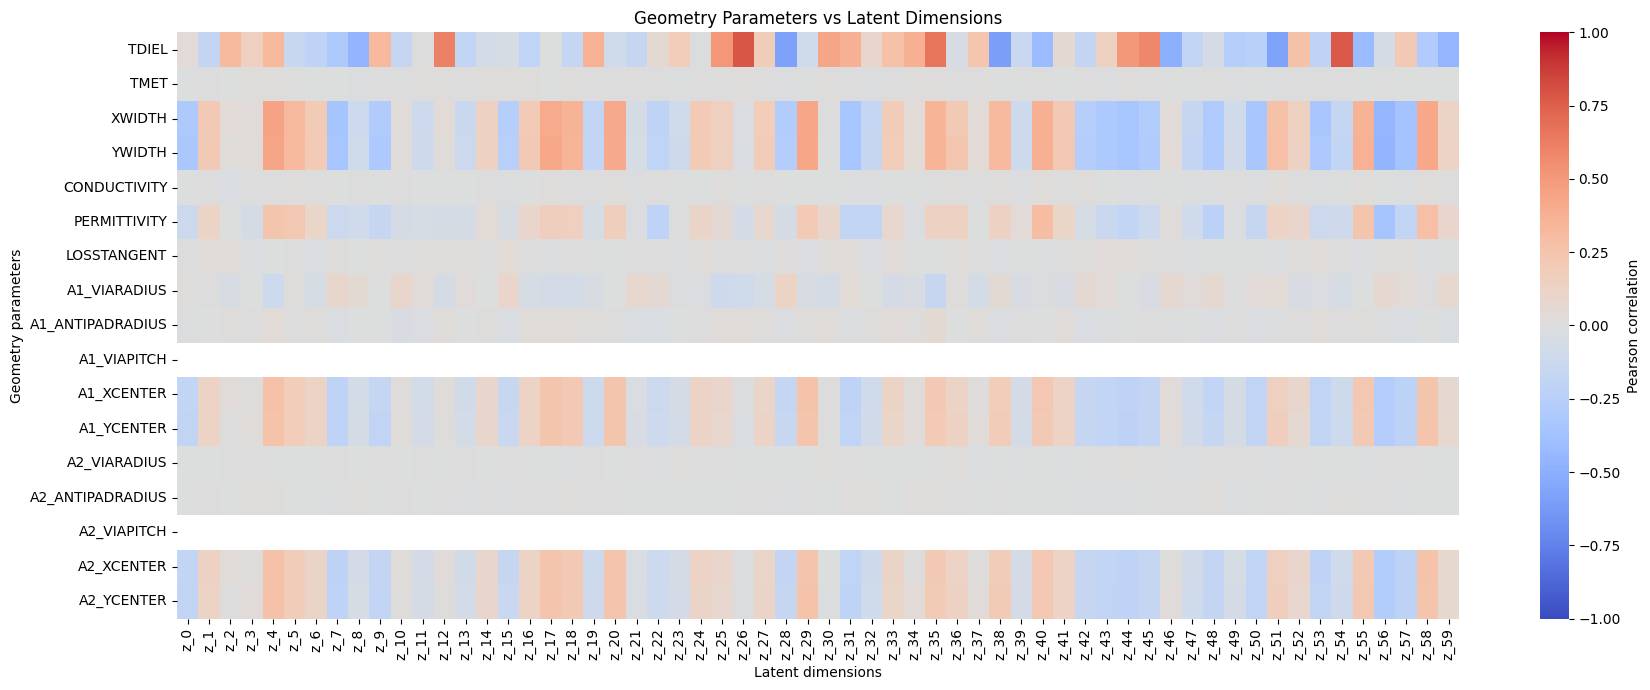

Saved heatmap to:
../../Results/relate_geometry_latent_space/figures/geometry_latent_correlation_heatmap.png


In [31]:
# Cell 8 - Plot full heatmap

heatmap_path = os.path.join(FIG_DIR, "geometry_latent_correlation_heatmap.png")
plt.figure(figsize=(18, 7))
sns.heatmap(
    corr_df,
    cmap="coolwarm",
    center=0.0,
    vmin=-1.0,
    vmax=1.0,
    cbar_kws={"label": "Pearson correlation"}
)

plt.title("Geometry Parameters vs Latent Dimensions")
plt.xlabel("Latent dimensions")
plt.ylabel("Geometry parameters")
plt.tight_layout()
plt.savefig(heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved heatmap to:")
print(heatmap_path)

In [32]:
# Cell 9 - Strongest latent dimension for each geometry parameter

best_latent_idx = np.abs(corr_matrix).argmax(axis=1)
best_latent_name = [f"z_{j}" for j in best_latent_idx]
best_corr_value = [corr_matrix[i, j] for i, j in enumerate(best_latent_idx)]
best_abs_corr = np.abs(best_corr_value)

best_corr_df = pd.DataFrame({
    "geometry_param": geo_columns,
    "best_latent_dim": best_latent_name,
    "corr_value": best_corr_value,
    "abs_corr_value": best_abs_corr
}).sort_values("abs_corr_value", ascending=False).reset_index(drop=True)

best_corr_df

,geometry_param,best_latent_dim,corr_value,abs_corr_value
0,TDIEL,z_26,0.783669,0.783669
1,YWIDTH,z_56,-0.463615,0.463615
2,XWIDTH,z_56,-0.458530,0.458530
3,PERMITTIVITY,z_56,-0.356524,0.356524
4,A2_YCENTER,z_56,-0.277174,0.277174
5,A2_XCENTER,z_56,-0.275526,0.275526
6,A1_XCENTER,z_56,-0.270045,0.270045
7,A1_YCENTER,z_56,-0.270028,0.270028
8,A1_VIARADIUS,z_35,-0.162304,0.162304
9,A1_ANTIPADRADIUS,z_35,0.050168,0.050168


In [33]:
# Cell 10 - Save strongest-correlation summary

best_corr_csv_path = os.path.join(RESULTS_DIR, "strongest_geometry_latent_links.csv")
best_corr_df.to_csv(best_corr_csv_path, index=False)

print("Saved strongest-correlation summary to:")
print(best_corr_csv_path)

Saved strongest-correlation summary to:
../../Results/relate_geometry_latent_space/strongest_geometry_latent_links.csv


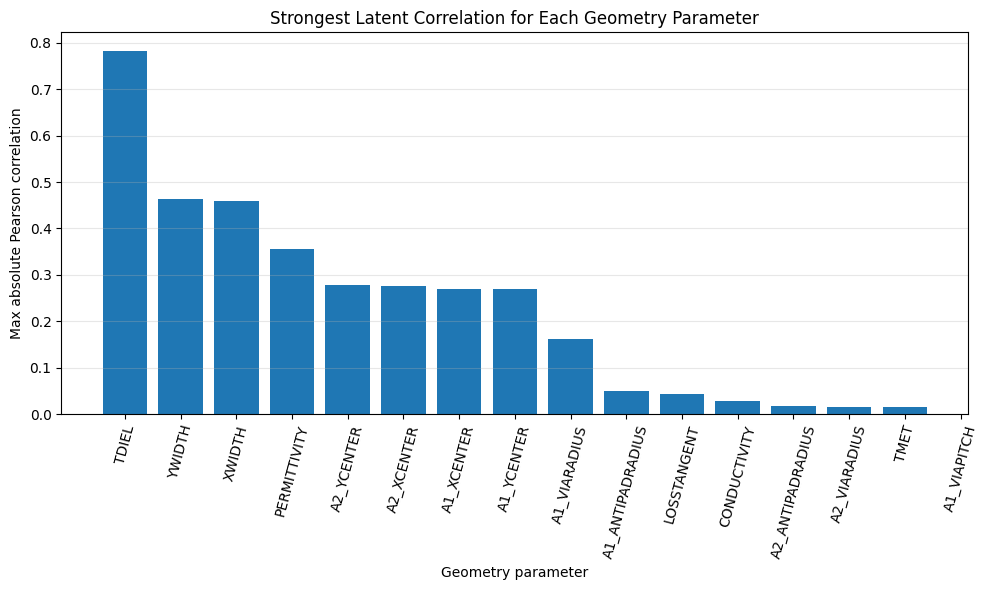

Saved bar plot to:
../../Results/relate_geometry_latent_space/figures/max_abs_correlation_per_geometry.png


In [35]:
# Cell 11 - Bar plot: strongest absolute correlation per geometry parameter

plot_df = best_corr_df.sort_values("abs_corr_value", ascending=False)
barplot_path = os.path.join(FIG_DIR, "max_abs_correlation_per_geometry.png")

plt.figure(figsize=(10, 6))
plt.bar(plot_df["geometry_param"], plot_df["abs_corr_value"])
plt.xticks(rotation=75)
plt.ylabel("Max absolute Pearson correlation")
plt.xlabel("Geometry parameter")
plt.title("Strongest Latent Correlation for Each Geometry Parameter")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(barplot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved bar plot to:")
print(barplot_path)

In [36]:
# Cell 12 - Compute Spearman correlation matrix

from scipy.stats import spearmanr

n_geo = GEO.shape[1]
n_lat = Z.shape[1]

spearman_matrix = np.zeros((n_geo, n_lat), dtype=np.float64)

for i in range(n_geo):
   for j in range(n_lat):
       corr, _ = spearmanr(GEO[:, i], Z[:, j])
       spearman_matrix[i, j] = corr

spearman_df = pd.DataFrame(
   spearman_matrix,
   index=geo_columns,
   columns=[f"z_{j}" for j in range(n_lat)]
)

print("Spearman matrix shape:", spearman_df.shape)
spearman_df.iloc[:5, :8]

/tmp/ipykernel_332252/1180524820.py:12: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = spearmanr(GEO[:, i], Z[:, j])


Spearman matrix shape: (17, 60)


,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
TDIEL,0.038155,-0.177728,0.332004,0.160798,0.347376,-0.151807,-0.218098,-0.346783
TMET,-0.002175,0.004937,-0.003373,0.011641,0.015995,0.002206,-0.000541,-0.006170
XWIDTH,-0.314851,0.213721,0.034876,0.022157,0.438839,0.324048,0.185040,-0.326546
YWIDTH,-0.330024,0.207057,0.018980,0.029147,0.427235,0.324449,0.186555,-0.321245
CONDUCTIVITY,-0.005765,0.004665,-0.028691,-0.002635,0.000865,0.009538,0.003736,-0.003809


In [37]:
# Cell 13 - Save Spearman correlation matrix

spearman_csv_path = os.path.join(RESULTS_DIR, "geometry_latent_spearman_matrix.csv")
spearman_df.to_csv(spearman_csv_path)

print("Saved Spearman matrix to:")
print(spearman_csv_path)

Saved Spearman matrix to:
../../Results/relate_geometry_latent_space/geometry_latent_spearman_matrix.csv


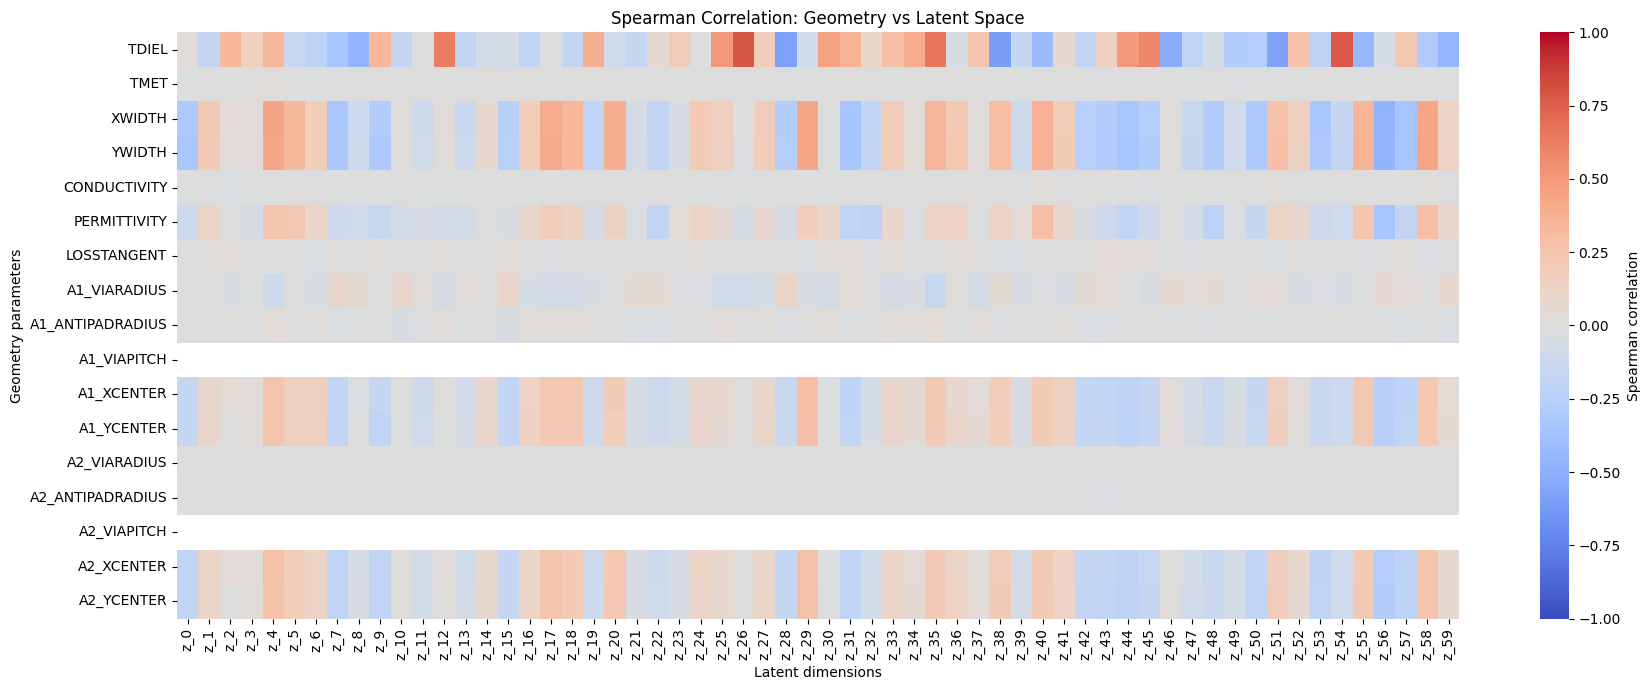

Saved heatmap to:
../../Results/relate_geometry_latent_space/figures/spearman_heatmap.png


In [38]:

# Cell 14,15 - Plot and Save Spearman heatmap


spearman_heatmap_path = os.path.join(FIG_DIR, "spearman_heatmap.png")
plt.figure(figsize=(18, 7))

sns.heatmap(
   spearman_df,
   cmap="coolwarm",
   center=0.0,
   vmin=-1.0,
   vmax=1.0,
   cbar_kws={"label": "Spearman correlation"}
)

plt.title("Spearman Correlation: Geometry vs Latent Space")
plt.xlabel("Latent dimensions")
plt.ylabel("Geometry parameters")

plt.tight_layout()
plt.savefig(spearman_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved heatmap to:")
print(spearman_heatmap_path)

In [39]:
# Cell 16 - Compare Pearson vs Spearman

comparison = []

for i, g_name in enumerate(geo_columns):
   pearson_best = np.max(np.abs(corr_matrix[i]))
   spearman_best = np.max(np.abs(spearman_matrix[i]))

   comparison.append({
       "geometry_param": g_name,
       "pearson_max": pearson_best,
       "spearman_max": spearman_best,
       "difference": spearman_best - pearson_best
   })

comparison_df = pd.DataFrame(comparison).sort_values("difference", ascending=False).reset_index(drop=True)

comparison_df


,geometry_param,pearson_max,spearman_max,difference
0,A1_XCENTER,0.270045,0.287455,0.017410
1,A1_YCENTER,0.270028,0.280455,0.010427
2,YWIDTH,0.463615,0.474010,0.010395
3,XWIDTH,0.458530,0.468909,0.010379
4,LOSSTANGENT,0.043088,0.046618,0.003530
5,CONDUCTIVITY,0.027462,0.028691,0.001230
6,TMET,0.014792,0.015995,0.001203
7,TDIEL,0.783669,0.784202,0.000533
8,A2_YCENTER,0.277174,0.276510,-0.000663
9,A2_VIARADIUS,0.015574,0.014246,-0.001328


In [16]:
# Cell 17 - Save Pearson vs Spearman comparison

comparison_csv_path = os.path.join(RESULTS_DIR, "pearson_vs_spearman.csv")
comparison_df.to_csv(comparison_csv_path, index=False)

print("Saved comparison to:")
print(comparison_csv_path)


Saved comparison to:
../../Results/relate_geometry_latent_space/pearson_vs_spearman.csv


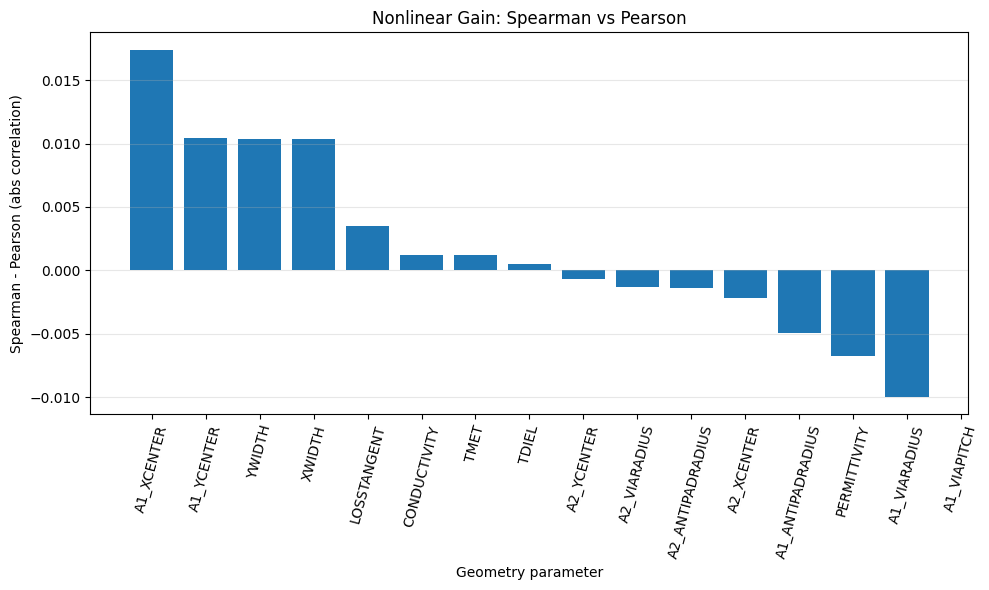

In [17]:
# Cell 18 - Plot Spearman improvement over Pearson

plt.figure(figsize=(10, 6))

plt.bar(comparison_df["geometry_param"], comparison_df["difference"])

plt.xticks(rotation=75)
plt.ylabel("Spearman - Pearson (abs correlation)")
plt.xlabel("Geometry parameter")
plt.title("Nonlinear Gain: Spearman vs Pearson")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

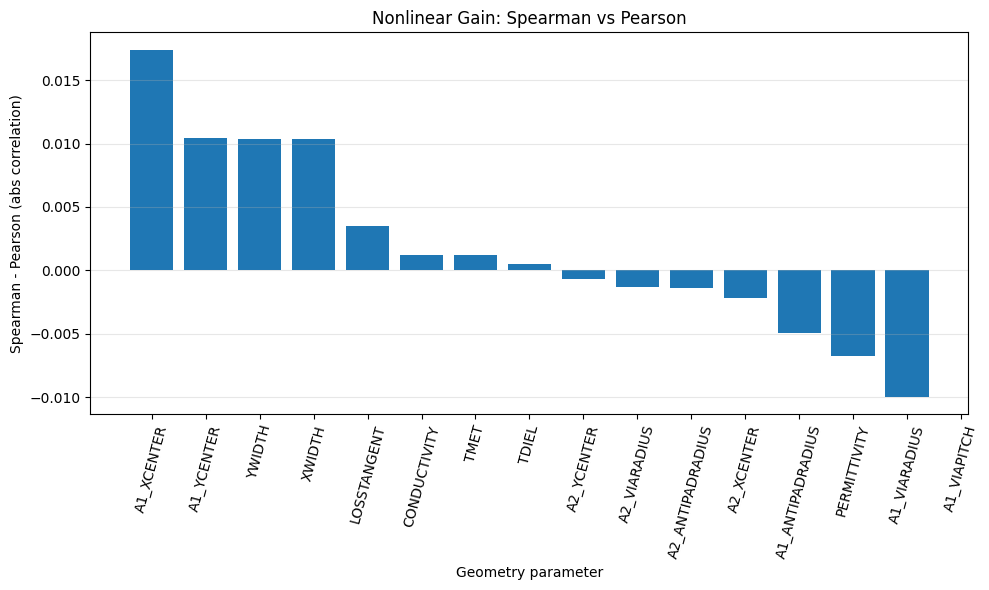

Saved plot to:
../../Results/relate_geometry_latent_space/figures/spearman_minus_pearson.png


In [18]:
# Cell 19 - Save improvement plot

improve_plot_path = os.path.join(FIG_DIR, "spearman_minus_pearson.png")

plt.figure(figsize=(10, 6))

plt.bar(comparison_df["geometry_param"], comparison_df["difference"])

plt.xticks(rotation=75)
plt.ylabel("Spearman - Pearson (abs correlation)")
plt.xlabel("Geometry parameter")
plt.title("Nonlinear Gain: Spearman vs Pearson")

plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(improve_plot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved plot to:")
print(improve_plot_path)


In [1]:
# Cell 20 - Import Mutual Information function

from sklearn.feature_selection import mutual_info_regression

In [8]:
# Cell 21 - Compute Mutual Information matrix

n_geo = GEO.shape[1]
n_lat = Z.shape[1]

mi_matrix = np.zeros((n_geo, n_lat), dtype=np.float64)

for i in range(n_geo):
    y = GEO[:, i]
    mi_scores = mutual_info_regression(
        X=Z,
        y=y,
        random_state=42
    )
    mi_matrix[i, :] = mi_scores

mi_df = pd.DataFrame(
    mi_matrix,
    index=geo_columns,
    columns=[f"z_{j}" for j in range(n_lat)]
)

print("MI matrix shape:", mi_df.shape)
mi_df.iloc[:5, :8]

MI matrix shape: (17, 60)


,z_0,z_1,z_2,z_3,z_4,z_5,z_6,z_7
TDIEL,0.024116,0.031770,0.090065,0.024883,0.088843,0.030936,0.037674,0.094342
TMET,0.000000,0.000000,0.003859,0.008818,0.008372,0.000000,0.000000,0.008645
XWIDTH,0.074068,0.032907,0.020885,0.013985,0.125761,0.061929,0.047601,0.083561
YWIDTH,0.069084,0.027190,0.022264,0.009362,0.120802,0.061639,0.038772,0.104423
CONDUCTIVITY,0.000000,0.008290,0.000000,0.004576,0.000000,0.000000,0.000000,0.000000


In [9]:
# Cell 22 - Save Mutual Information matrix

mi_csv_path = os.path.join(RESULTS_DIR, "geometry_latent_mutual_information_matrix.csv")
mi_df.to_csv(mi_csv_path)

print("Saved MI matrix to:")
print(mi_csv_path)

Saved MI matrix to:
../../Results/relate_geometry_latent_space/geometry_latent_mutual_information_matrix.csv


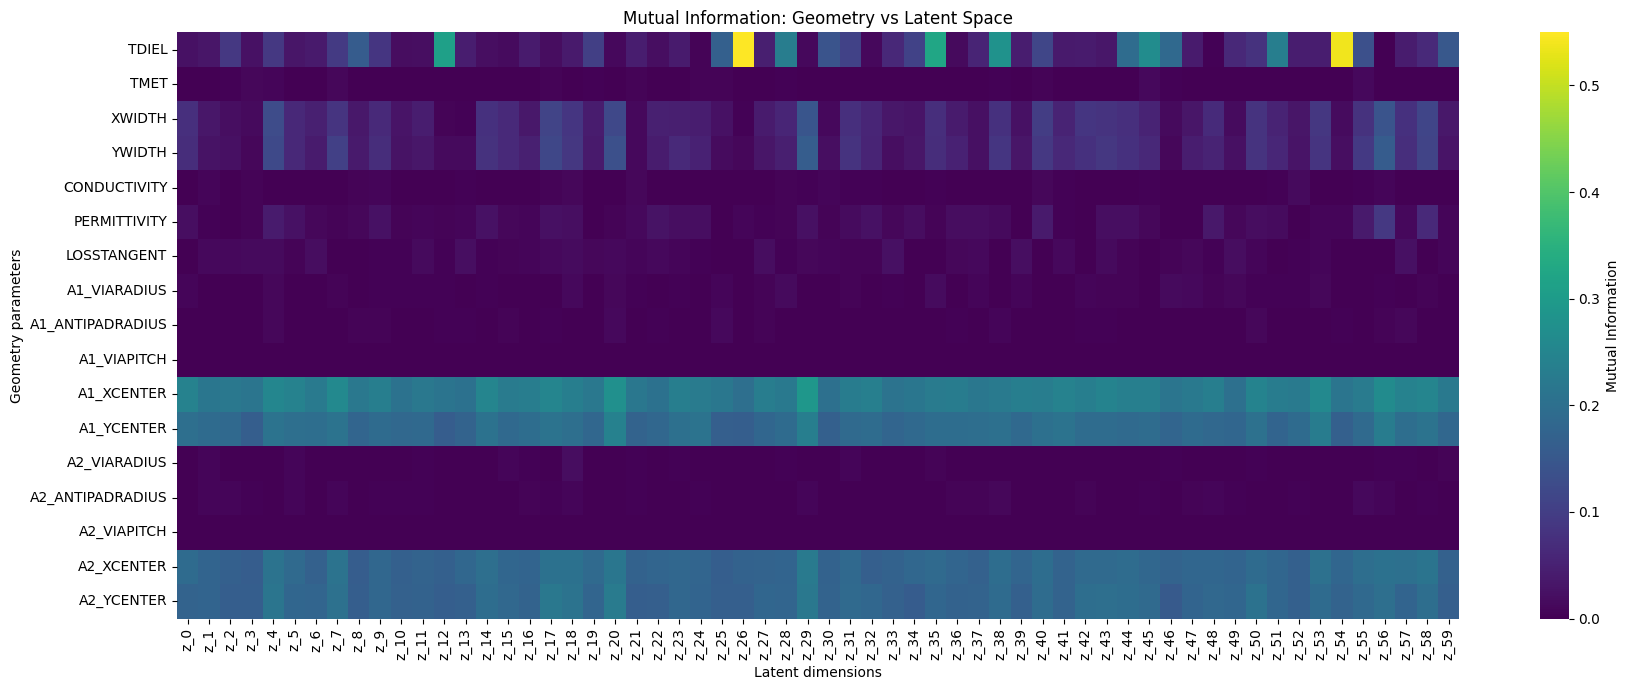

In [10]:
# Cell 23 - Plot MI heatmap

plt.figure(figsize=(18, 7))

sns.heatmap(
    mi_df,
    cmap="viridis",
    cbar_kws={"label": "Mutual Information"}
)

plt.title("Mutual Information: Geometry vs Latent Space")
plt.xlabel("Latent dimensions")
plt.ylabel("Geometry parameters")

plt.tight_layout()
plt.show()

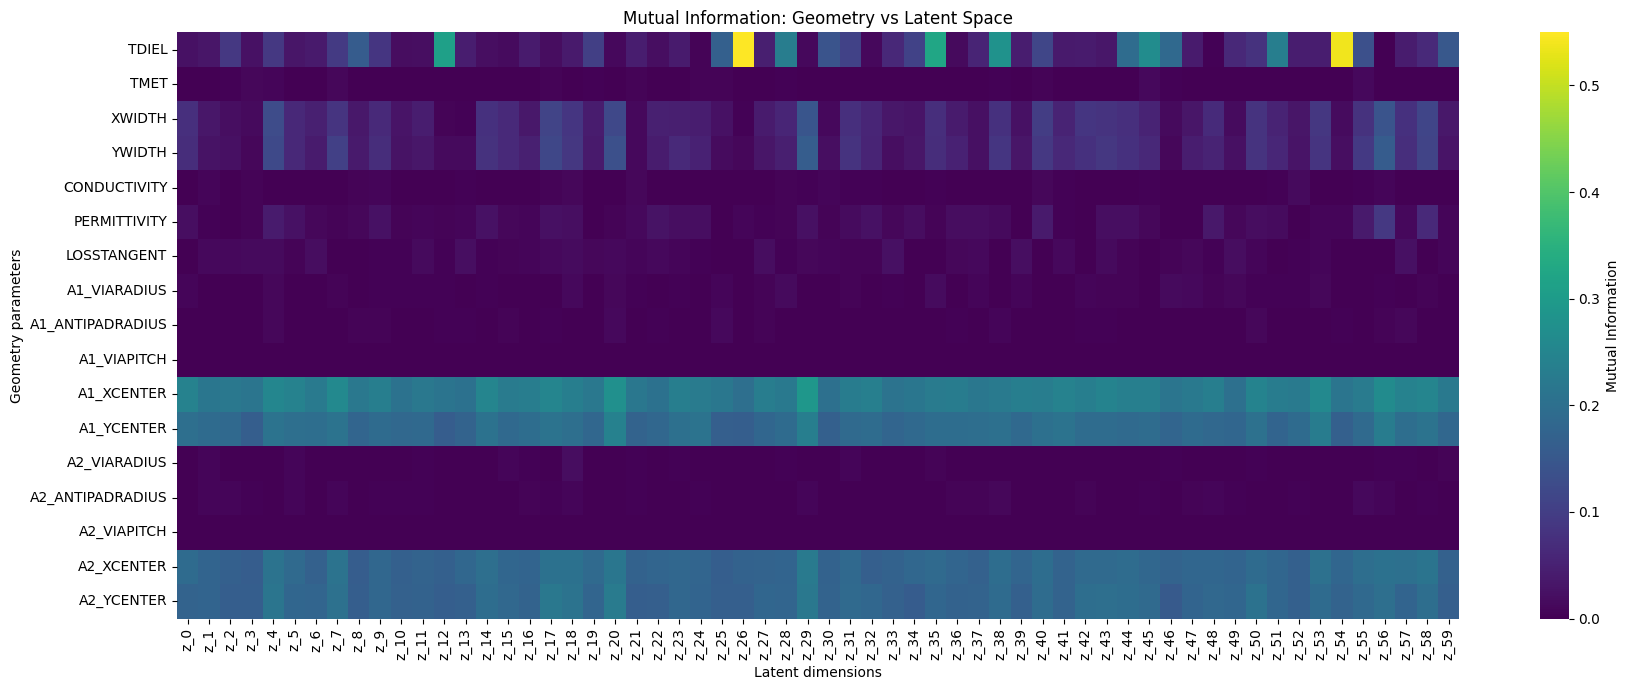

Saved MI heatmap to:
../../Results/relate_geometry_latent_space/figures/mutual_information_heatmap.png


In [11]:
# Cell 24 - Save MI heatmap

mi_heatmap_path = os.path.join(FIG_DIR, "mutual_information_heatmap.png")

plt.figure(figsize=(18, 7))

sns.heatmap(
    mi_df,
    cmap="viridis",
    cbar_kws={"label": "Mutual Information"}
)

plt.title("Mutual Information: Geometry vs Latent Space")
plt.xlabel("Latent dimensions")
plt.ylabel("Geometry parameters")

plt.tight_layout()
plt.savefig(mi_heatmap_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved MI heatmap to:")
print(mi_heatmap_path)

In [12]:
# Cell 25 - Strongest latent dimension by MI for each geometry parameter

best_mi_idx = mi_matrix.argmax(axis=1)
best_mi_name = [f"z_{j}" for j in best_mi_idx]
best_mi_value = [mi_matrix[i, j] for i, j in enumerate(best_mi_idx)]

best_mi_df = pd.DataFrame({
    "geometry_param": geo_columns,
    "best_latent_dim": best_mi_name,
    "mi_value": best_mi_value
}).sort_values("mi_value", ascending=False).reset_index(drop=True)

best_mi_df

,geometry_param,best_latent_dim,mi_value
0,TDIEL,z_26,0.549840
1,A1_XCENTER,z_29,0.290936
2,A1_YCENTER,z_20,0.238720
3,A2_YCENTER,z_20,0.227559
4,A2_XCENTER,z_29,0.224507
5,YWIDTH,z_29,0.160972
6,XWIDTH,z_29,0.143983
7,PERMITTIVITY,z_56,0.089201
8,LOSSTANGENT,z_57,0.023390
9,A2_VIARADIUS,z_18,0.017367


In [13]:
# Cell 26 - Save strongest MI summary

best_mi_csv_path = os.path.join(RESULTS_DIR, "strongest_geometry_latent_mi_links.csv")
best_mi_df.to_csv(best_mi_csv_path, index=False)

print("Saved strongest MI summary to:")
print(best_mi_csv_path)

Saved strongest MI summary to:
../../Results/relate_geometry_latent_space/strongest_geometry_latent_mi_links.csv


In [40]:
# Cell 27 - Compare strongest Pearson, Spearman, and MI by geometry parameter

pearson_best = np.max(np.abs(corr_matrix), axis=1)
spearman_best = np.max(np.abs(spearman_matrix), axis=1)
mi_best = np.max(mi_matrix, axis=1)

summary_compare_df = pd.DataFrame({
    "geometry_param": geo_columns,
    "pearson_max_abs": pearson_best,
    "spearman_max_abs": spearman_best,
    "mi_max": mi_best
}).sort_values("mi_max", ascending=False).reset_index(drop=True)

summary_compare_df

,geometry_param,pearson_max_abs,spearman_max_abs,mi_max
0,TDIEL,0.783669,0.784202,0.549840
1,A1_XCENTER,0.270045,0.287455,0.290936
2,A1_YCENTER,0.270028,0.280455,0.238720
3,A2_YCENTER,0.277174,0.276510,0.227559
4,A2_XCENTER,0.275526,0.273314,0.224507
5,YWIDTH,0.463615,0.474010,0.160972
6,XWIDTH,0.458530,0.468909,0.143983
7,PERMITTIVITY,0.356524,0.349783,0.089201
8,LOSSTANGENT,0.043088,0.046618,0.023390
9,A2_VIARADIUS,0.015574,0.014246,0.017367


In [41]:
# Cell 28 - Save combined summary

summary_compare_csv_path = os.path.join(RESULTS_DIR, "pearson_spearman_mi_summary.csv")
summary_compare_df.to_csv(summary_compare_csv_path, index=False)

print("Saved combined summary to:")
print(summary_compare_csv_path)

Saved combined summary to:
../../Results/relate_geometry_latent_space/pearson_spearman_mi_summary.csv


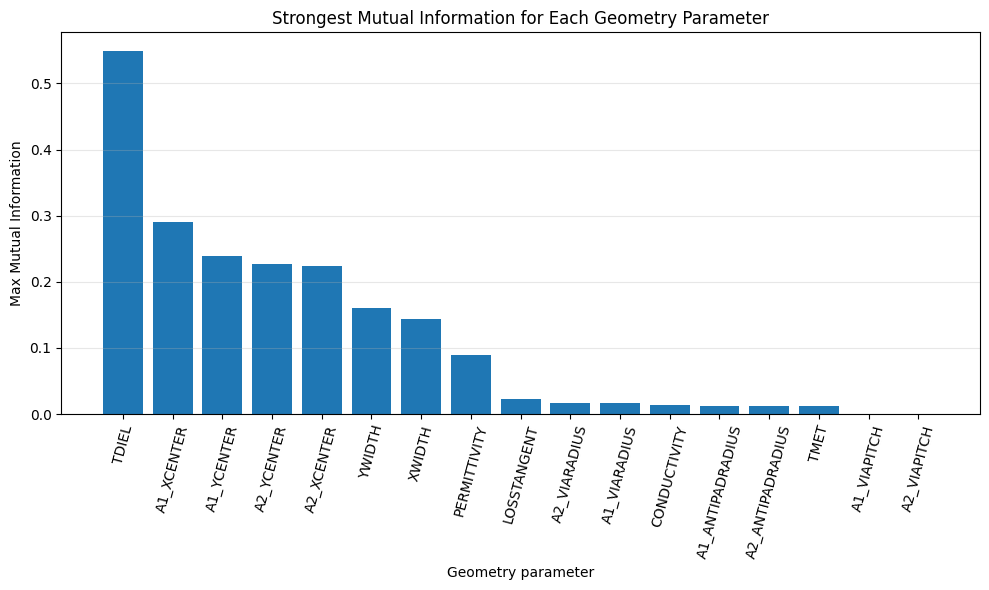

In [42]:
# Cell 29 - Bar plot of strongest MI per geometry parameter

plot_mi_df = best_mi_df.sort_values("mi_value", ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(plot_mi_df["geometry_param"], plot_mi_df["mi_value"])

plt.xticks(rotation=75)
plt.ylabel("Max Mutual Information")
plt.xlabel("Geometry parameter")
plt.title("Strongest Mutual Information for Each Geometry Parameter")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

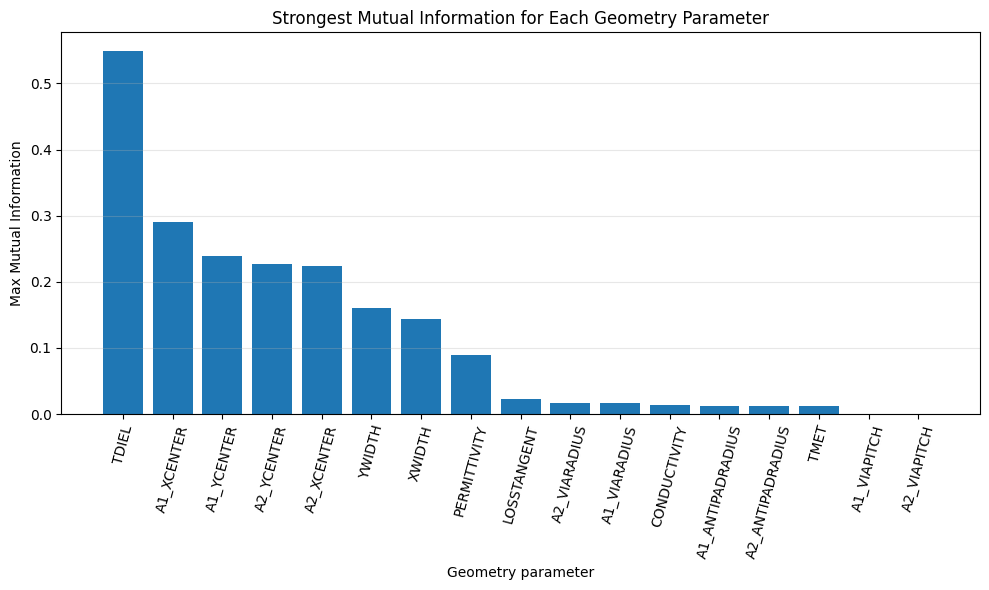

Saved MI bar plot to:
../../Results/relate_geometry_latent_space/figures/max_mutual_information_per_geometry.png


In [43]:
# Cell 30 - Save MI bar plot

mi_barplot_path = os.path.join(FIG_DIR, "max_mutual_information_per_geometry.png")

plt.figure(figsize=(10, 6))
plt.bar(plot_mi_df["geometry_param"], plot_mi_df["mi_value"])

plt.xticks(rotation=75)
plt.ylabel("Max Mutual Information")
plt.xlabel("Geometry parameter")
plt.title("Strongest Mutual Information for Each Geometry Parameter")
plt.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(mi_barplot_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved MI bar plot to:")
print(mi_barplot_path)

In [44]:
# Cell 31 - Find likely nonlinear dependencies

nonlinear_candidates = summary_compare_df.copy()

# simple heuristic:
# strong MI but weak linear/monotonic correlation
nonlinear_candidates["nonlinear_hint"] = (
    (nonlinear_candidates["mi_max"] > nonlinear_candidates["mi_max"].median()) &
    (nonlinear_candidates["pearson_max_abs"] < 0.3) &
    (nonlinear_candidates["spearman_max_abs"] < 0.3)
)

nonlinear_candidates.sort_values(
    ["nonlinear_hint", "mi_max"],
    ascending=[False, False]
).reset_index(drop=True)

,geometry_param,pearson_max_abs,spearman_max_abs,mi_max,nonlinear_hint
0,A1_XCENTER,0.270045,0.287455,0.290936,True
1,A1_YCENTER,0.270028,0.280455,0.238720,True
2,A2_YCENTER,0.277174,0.276510,0.227559,True
3,A2_XCENTER,0.275526,0.273314,0.224507,True
4,TDIEL,0.783669,0.784202,0.549840,False
5,YWIDTH,0.463615,0.474010,0.160972,False
6,XWIDTH,0.458530,0.468909,0.143983,False
7,PERMITTIVITY,0.356524,0.349783,0.089201,False
8,LOSSTANGENT,0.043088,0.046618,0.023390,False
9,A2_VIARADIUS,0.015574,0.014246,0.017367,False


In [45]:
# Cell 32 - MI summary

print("Mutual Information summary")
print("-" * 50)
print("MI matrix shape:", mi_df.shape)

print("\nTop 10 geometry parameters by strongest MI:")
display(best_mi_df.head(10))

print("\nSaved outputs:")
print("1.", mi_csv_path)
print("2.", best_mi_csv_path)
print("3.", summary_compare_csv_path)
print("4.", mi_heatmap_path)
print("5.", mi_barplot_path)

Mutual Information summary
--------------------------------------------------
MI matrix shape: (17, 60)

Top 10 geometry parameters by strongest MI:


,geometry_param,best_latent_dim,mi_value
0,TDIEL,z_26,0.549840
1,A1_XCENTER,z_29,0.290936
2,A1_YCENTER,z_20,0.238720
3,A2_YCENTER,z_20,0.227559
4,A2_XCENTER,z_29,0.224507
5,YWIDTH,z_29,0.160972
6,XWIDTH,z_29,0.143983
7,PERMITTIVITY,z_56,0.089201
8,LOSSTANGENT,z_57,0.023390
9,A2_VIARADIUS,z_18,0.017367



Saved outputs:
1. ../../Results/relate_geometry_latent_space/geometry_latent_mutual_information_matrix.csv
2. ../../Results/relate_geometry_latent_space/strongest_geometry_latent_mi_links.csv
3. ../../Results/relate_geometry_latent_space/pearson_spearman_mi_summary.csv
4. ../../Results/relate_geometry_latent_space/figures/mutual_information_heatmap.png
5. ../../Results/relate_geometry_latent_space/figures/max_mutual_information_per_geometry.png


# Binned Analysis

In [ ]:
# Setup everything needed for geometry-impact plots

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Sources.dataset import PDNDataset

# ----------------------------
# 1) Load full dataset
# ----------------------------
ds_full = PDNDataset(
   data_dir=RUN_CFG["data_dir"],
   csv_file=RUN_CFG["csv_file"],
   subset_size=None,          # full dataset
   repr_name=RUN_CFG["repr_name"],
   subset_sampling="first",
   subset_seed=42,
)

print("Dataset loaded.")
print("Samples:", len(ds_full))
print("Impedance shape:", tuple(ds_full.impedance_data.shape))

# ----------------------------
# 2) Load geometry CSV
# ----------------------------
db_df = pd.read_csv(RUN_CFG["csv_file"])
print("Geometry CSV shape:", db_df.shape)

# ----------------------------
# 3) Build frequency axis
# ----------------------------
if hasattr(ds_full, "freq_hz") and ds_full.freq_hz is not None:
   freq_hz = ds_full.freq_hz.cpu().numpy() if hasattr(ds_full.freq_hz, "cpu") else np.asarray(ds_full.freq_hz)
else:
   raise ValueError("freq_hz not found in ds_full. Check dataset loading.")

freq_mhz = freq_hz / 1e6
print("Frequency points:", len(freq_mhz))
print("Freq range (MHz):", float(freq_mhz[0]), "to", float(freq_mhz[-1]))

# ----------------------------
# 4) Function: plot binned average magnitude for one parameter
#    OUTPUT IN OHM, LOG-LOG AXES
# ----------------------------
def plot_param_bins(param_name, n_bins=5, max_per_bin=200, add_target_line=False, target_ohm=0.1):
   """
   Plot average |Z11| in Ohm for quantile bins of one geometry parameter.

   param_name      : geometry column name in db_df
   n_bins          : number of quantile bins
   max_per_bin     : max number of samples averaged per bin
   add_target_line : if True, draw horizontal target impedance line
   target_ohm      : target impedance value in Ohm
   """
   if param_name not in db_df.columns:
       raise ValueError(f"{param_name} not found in db_df columns")

   values = db_df[param_name].values

   # keep only finite values
   valid_mask = np.isfinite(values)
   if valid_mask.sum() != len(values):
       print(f"Warning: dropping {len(values) - valid_mask.sum()} invalid rows for {param_name}")

   values_valid = values[valid_mask]
   row_ids_valid = np.where(valid_mask)[0]

   # constant-parameter check
   if np.nanstd(values_valid) < 1e-12:
       print(f"{param_name} is constant or nearly constant. No meaningful bin plot.")
       return

   # quantile bins
   bins = pd.qcut(values_valid, q=n_bins, duplicates="drop")

   plt.figure(figsize=(8, 5))

   for b in bins.categories:
       idx_local = np.where(bins == b)[0]
       rows = row_ids_valid[idx_local]

       curves = []
       for r in rows[:max_per_bin]:
           x = ds_full.impedance_data[r]
           x = x.cpu().numpy() if hasattr(x, "cpu") else x.numpy()

           # x[0, :] = ln|Z|
           mag_ohm = np.exp(x[0, :])   # ln|Z| -> |Z| in Ohm
           curves.append(mag_ohm)

       if len(curves) == 0:
           continue

       avg_curve = np.mean(curves, axis=0)
       plt.loglog(freq_mhz, avg_curve, label=str(b))

   if add_target_line:
       plt.axhline(target_ohm, linestyle="--", alpha=0.6, label=f"Target = {target_ohm} Ω")

   plt.xlabel("Frequency (MHz)")
   plt.ylabel("|Z11| (Ohm)")
   plt.title(f"Binned effect of {param_name}")
   plt.grid(True, which="both", alpha=0.3)
   plt.legend(fontsize=8)
   plt.tight_layout()
   plt.show()

# ----------------------------
# 5) Top-6 parameters from MI
# ----------------------------
top6_params = [
   "TDIEL",
   "A1_XCENTER",
   "A1_YCENTER",
   "A2_YCENTER",
   "A2_XCENTER",
   "YWIDTH",
]

print("Top-6 parameters ready:", top6_params)

Loading cached dataset: ../../Data/data_cache_ln_phase_FULL_first_seedNA_geo_raw.pt
Dataset loaded.
Samples: 20000
Impedance shape: (20000, 2, 334)
Geometry CSV shape: (20000, 18)
Frequency points: 334
Freq range (MHz): 1.0 to 1000.0
Top-6 parameters ready: ['TDIEL', 'A1_XCENTER', 'A1_YCENTER', 'A2_YCENTER', 'A2_XCENTER', 'YWIDTH']


/home/tekb/Master_Thesis_KB/CodesAndData/Sources/dataset.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cached = torch.load(self.cache_path, map_location="cpu")  # ma

In [ ]:
# Cell X - Setup everything needed for geometry-impact plots



import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys



from Sources.dataset import PDNDataset


# ----------------------------
# 1) Load full dataset
# ----------------------------
ds_full = PDNDataset(
   data_dir=RUN_CFG["data_dir"],
   csv_file=RUN_CFG["csv_file"],
   subset_size=None,          # full dataset
   repr_name=RUN_CFG["repr_name"],
   subset_sampling="first",
   subset_seed=42,
)

print("Dataset loaded.")
print("Samples:", len(ds_full))
print("Impedance shape:", tuple(ds_full.impedance_data.shape))

# ----------------------------
# 2) Load geometry CSV
# ----------------------------
db_df = pd.read_csv(RUN_CFG["csv_file"])
print("Geometry CSV shape:", db_df.shape)

# ----------------------------
# 2a) Create physics-based derived position features
#     A1 is considered the observation port for Z11
# ----------------------------
required_cols = [
    "XWIDTH", "YWIDTH",
    "A1_XCENTER", "A1_YCENTER",
    "A2_XCENTER", "A2_YCENTER",
]

missing_cols = [c for c in required_cols if c not in db_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns in parameter CSV: {missing_cols}")

# ---- A1: observation-port position features ----
# Distance from board center in x and y direction
db_df["A1_DX_CENTER"] = np.abs(db_df["A1_XCENTER"] - db_df["XWIDTH"] / 2.0)
db_df["A1_DY_CENTER"] = np.abs(db_df["A1_YCENTER"] - db_df["YWIDTH"] / 2.0)

# Euclidean distance of A1 from board center
db_df["A1_D_CENTER"] = np.sqrt(
    db_df["A1_DX_CENTER"]**2 + db_df["A1_DY_CENTER"]**2
)

# Distance from A1 to each PCB edge
db_df["A1_D_LEFT"] = db_df["A1_XCENTER"]
db_df["A1_D_RIGHT"] = db_df["XWIDTH"] - db_df["A1_XCENTER"]
db_df["A1_D_BOTTOM"] = db_df["A1_YCENTER"]
db_df["A1_D_TOP"] = db_df["YWIDTH"] - db_df["A1_YCENTER"]

# Distance from A1 to nearest PCB edge
db_df["A1_D_NEAREST_EDGE"] = np.minimum.reduce([
    db_df["A1_D_LEFT"].values,
    db_df["A1_D_RIGHT"].values,
    db_df["A1_D_BOTTOM"].values,
    db_df["A1_D_TOP"].values,
])

# Normalized A1 coordinates, useful for checking left/right and bottom/top trends
db_df["A1_X_NORM"] = db_df["A1_XCENTER"] / db_df["XWIDTH"]
db_df["A1_Y_NORM"] = db_df["A1_YCENTER"] / db_df["YWIDTH"]

# ---- A2: secondary array position features ----
# For Z11 at A1, A2 is less direct than A1, but can still influence the structure.
db_df["A2_DX_CENTER"] = np.abs(db_df["A2_XCENTER"] - db_df["XWIDTH"] / 2.0)
db_df["A2_DY_CENTER"] = np.abs(db_df["A2_YCENTER"] - db_df["YWIDTH"] / 2.0)

db_df["A2_D_CENTER"] = np.sqrt(
    db_df["A2_DX_CENTER"]**2 + db_df["A2_DY_CENTER"]**2
)

db_df["A2_D_LEFT"] = db_df["A2_XCENTER"]
db_df["A2_D_RIGHT"] = db_df["XWIDTH"] - db_df["A2_XCENTER"]
db_df["A2_D_BOTTOM"] = db_df["A2_YCENTER"]
db_df["A2_D_TOP"] = db_df["YWIDTH"] - db_df["A2_YCENTER"]

db_df["A2_D_NEAREST_EDGE"] = np.minimum.reduce([
    db_df["A2_D_LEFT"].values,
    db_df["A2_D_RIGHT"].values,
    db_df["A2_D_BOTTOM"].values,
    db_df["A2_D_TOP"].values,
])

db_df["A2_X_NORM"] = db_df["A2_XCENTER"] / db_df["XWIDTH"]
db_df["A2_Y_NORM"] = db_df["A2_YCENTER"] / db_df["YWIDTH"]

# ---- Distance between A1 and A2 ----
# Useful if you later discuss transfer effects or interaction between arrays.
db_df["A1_A2_DX"] = np.abs(db_df["A2_XCENTER"] - db_df["A1_XCENTER"])
db_df["A1_A2_DY"] = np.abs(db_df["A2_YCENTER"] - db_df["A1_YCENTER"])
db_df["A1_A2_DISTANCE"] = np.sqrt(
    db_df["A1_A2_DX"]**2 + db_df["A1_A2_DY"]**2
)

print("\nDerived position features added:")
derived_cols = [
    "A1_DX_CENTER", "A1_DY_CENTER", "A1_D_CENTER",
    "A1_D_NEAREST_EDGE", "A1_X_NORM", "A1_Y_NORM",
    "A2_DX_CENTER", "A2_DY_CENTER", "A2_D_CENTER",
    "A2_D_NEAREST_EDGE", "A2_X_NORM", "A2_Y_NORM",
    "A1_A2_DISTANCE",
]
print(derived_cols)

# ----------------------------
# 3) Build frequency axis
# ----------------------------
if hasattr(ds_full, "freq_hz") and ds_full.freq_hz is not None:
   freq_hz = ds_full.freq_hz.cpu().numpy() if hasattr(ds_full.freq_hz, "cpu") else np.asarray(ds_full.freq_hz)
else:
   raise ValueError("freq_hz not found in ds_full. Check dataset loading.")

freq_mhz = freq_hz / 1e6
print("\nFrequency points:", len(freq_mhz))
print("Freq range (MHz):", float(freq_mhz[0]), "to", float(freq_mhz[-1]))

# ----------------------------
# 4) Function: plot binned average magnitude for one parameter
#    OUTPUT IN OHM, LOG-LOG AXES
# ----------------------------
def plot_param_bins(
    param_name,
    n_bins=5,
    max_per_bin=200,
    add_target_line=False,
    target_ohm=0.1,
    random_seed=42,
):
   """
   Plot average |Z11| in Ohm for quantile bins of one geometry parameter.

   param_name      : geometry column name in db_df
   n_bins          : number of quantile bins
   max_per_bin     : max number of samples averaged per bin
   add_target_line : if True, draw horizontal target impedance line
   target_ohm      : target impedance value in Ohm
   random_seed     : seed for deterministic random sampling inside each bin
   """
   if param_name not in db_df.columns:
       raise ValueError(f"{param_name} not found in db_df columns")

   values = db_df[param_name].values.astype(float)

   # keep only finite values
   valid_mask = np.isfinite(values)
   if valid_mask.sum() != len(values):
       print(f"Warning: dropping {len(values) - valid_mask.sum()} invalid rows for {param_name}")

   values_valid = values[valid_mask]
   row_ids_valid = np.where(valid_mask)[0]

   # constant-parameter check
   if np.nanstd(values_valid) < 1e-12:
       print(f"{param_name} is constant or nearly constant. No meaningful bin plot.")
       return

   # quantile bins
   bins = pd.qcut(values_valid, q=n_bins, duplicates="drop")

   plt.figure(figsize=(8, 5))
   rng = np.random.default_rng(random_seed)

   print(f"\nBinned effect of {param_name}")
   print("-" * 60)

   for b in bins.categories:
       idx_local = np.where(bins == b)[0]
       rows = row_ids_valid[idx_local]

       # Random but reproducible sampling inside each bin to avoid order bias
       if len(rows) > max_per_bin:
           rows_used = rng.choice(rows, size=max_per_bin, replace=False)
       else:
           rows_used = rows

       curves = []
       for r in rows_used:
           x = ds_full.impedance_data[r]
           x = x.cpu().numpy() if hasattr(x, "cpu") else x.numpy()

           # x[0, :] = ln|Z|
           mag_ohm = np.exp(x[0, :])   # ln|Z| -> |Z| in Ohm
           curves.append(mag_ohm)

       if len(curves) == 0:
           continue

       avg_curve = np.mean(curves, axis=0)

       label = f"{b.left:.3g} to {b.right:.3g}"
       plt.loglog(freq_mhz, avg_curve, label=label)

       print(f"{label:>25s} | total samples: {len(rows):5d} | used: {len(rows_used):4d}")

   if add_target_line:
       plt.axhline(target_ohm, linestyle="--", alpha=0.6, label=f"Target = {target_ohm} Ω")

   plt.xlabel("Frequency (MHz)")
   plt.ylabel("|Z11| (Ohm)")
   plt.title(f"Binned effect of {param_name}")
   plt.grid(True, which="both", alpha=0.3)
   plt.legend(fontsize=8)
   plt.tight_layout()
   plt.show()

# ----------------------------
# 5) Parameters to study
# ----------------------------

# Original top parameters from MI/statistical dependence
top6_params_raw = [
   "TDIEL",
   "A1_XCENTER",
   "A1_YCENTER",
   "A2_YCENTER",
   "A2_XCENTER",
   "YWIDTH",
]

# More physically interpretable parameters for A1 as observation port
top_params_physical = [
   "TDIEL",
   "XWIDTH",
   "YWIDTH",
   "A1_D_NEAREST_EDGE",
   "A1_D_CENTER",
   "A1_DX_CENTER",
   "A1_DY_CENTER",
   "A1_X_NORM",
   "A1_Y_NORM",
]

print("\nRaw top parameters:")
print(top6_params_raw)

print("\nPhysically interpretable parameters for A1 observation port:")
print(top_params_physical)

Loading cached dataset: ../../Data/data_cache_ln_phase_FULL_first_seedNA_geo_raw.pt
Dataset loaded.
Samples: 20000
Impedance shape: (20000, 2, 334)
Geometry CSV shape: (20000, 18)

Derived position features added:
['A1_DX_CENTER', 'A1_DY_CENTER', 'A1_D_CENTER', 'A1_D_NEAREST_EDGE', 'A1_X_NORM', 'A1_Y_NORM', 'A2_DX_CENTER', 'A2_DY_CENTER', 'A2_D_CENTER', 'A2_D_NEAREST_EDGE', 'A2_X_NORM', 'A2_Y_NORM', 'A1_A2_DISTANCE']

Frequency points: 334
Freq range (MHz): 1.0 to 1000.0

Raw top parameters:
['TDIEL', 'A1_XCENTER', 'A1_YCENTER', 'A2_YCENTER', 'A2_XCENTER', 'YWIDTH']

Physically interpretable parameters for A1 observation port:
['TDIEL', 'XWIDTH', 'YWIDTH', 'A1_D_NEAREST_EDGE', 'A1_D_CENTER', 'A1_DX_CENTER', 'A1_DY_CENTER', 'A1_X_NORM', 'A1_Y_NORM']


/home/tekb/Master_Thesis_KB/CodesAndData/Sources/dataset.py:128: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  cached = torch.load(self.cache_path, map_location="cpu")  # ma


Binned effect of A1_XCENTER
------------------------------------------------------------
          150 to 1.45e+03 | total samples:  4013 | used:  200
     1.45e+03 to 2.95e+03 | total samples:  3999 | used:  200
      2.95e+03 to 5.1e+03 | total samples:  4021 | used:  200
      5.1e+03 to 8.25e+03 | total samples:  3990 | used:  200
     8.25e+03 to 1.76e+04 | total samples:  3977 | used:  200


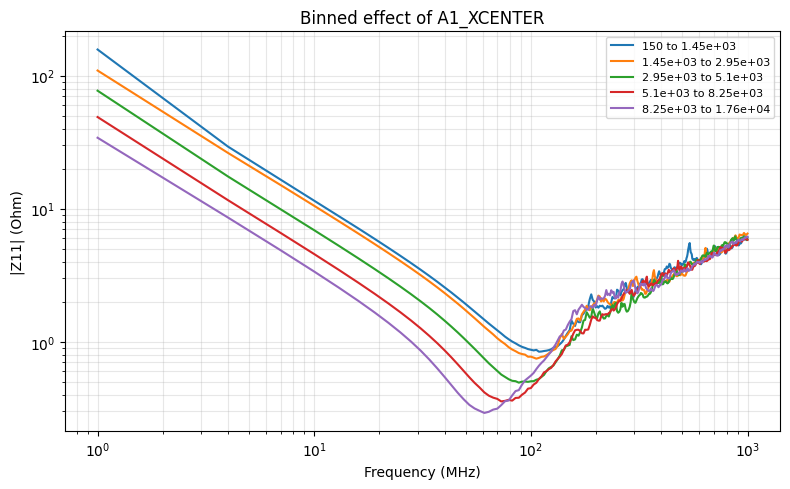


Binned effect of A1_YCENTER
------------------------------------------------------------
          150 to 1.55e+03 | total samples:  4137 | used:  200
     1.55e+03 to 3.05e+03 | total samples:  3963 | used:  200
     3.05e+03 to 5.15e+03 | total samples:  3904 | used:  200
      5.15e+03 to 8.4e+03 | total samples:  4044 | used:  200
      8.4e+03 to 1.78e+04 | total samples:  3952 | used:  200


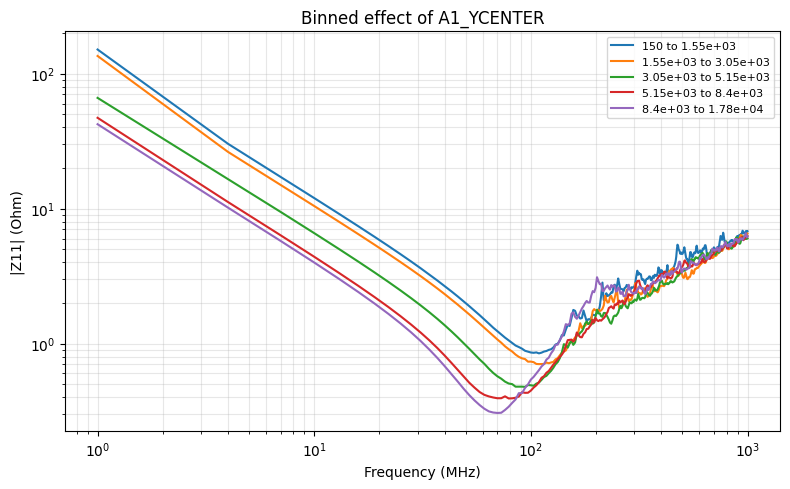


Binned effect of A1_D_NEAREST_EDGE
------------------------------------------------------------
              99.2 to 472 | total samples:  4000 | used:  200
               472 to 900 | total samples:  4213 | used:  200
          900 to 1.43e+03 | total samples:  3787 | used:  200
     1.43e+03 to 2.35e+03 | total samples:  4000 | used:  200
      2.35e+03 to 7.8e+03 | total samples:  4000 | used:  200


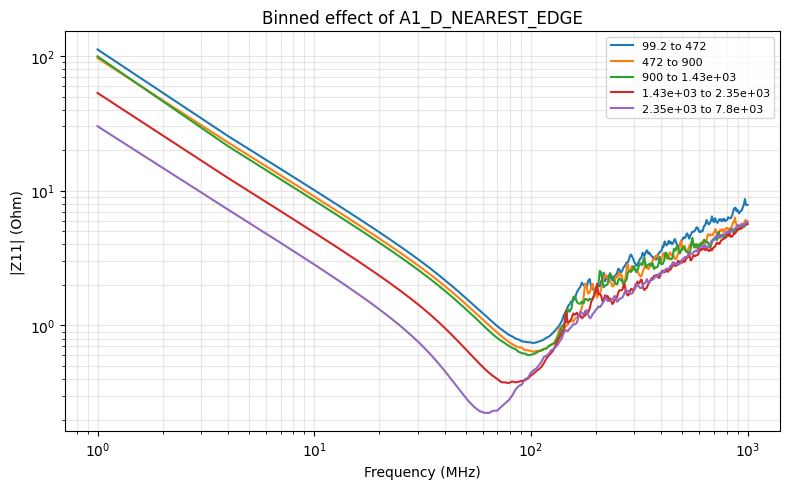


Binned effect of A1_D_CENTER
------------------------------------------------------------
         16.6 to 1.88e+03 | total samples:  4000 | used:  200
     1.88e+03 to 3.02e+03 | total samples:  4000 | used:  200
     3.02e+03 to 4.26e+03 | total samples:  4000 | used:  200
      4.26e+03 to 5.8e+03 | total samples:  4000 | used:  200
      5.8e+03 to 1.15e+04 | total samples:  4000 | used:  200


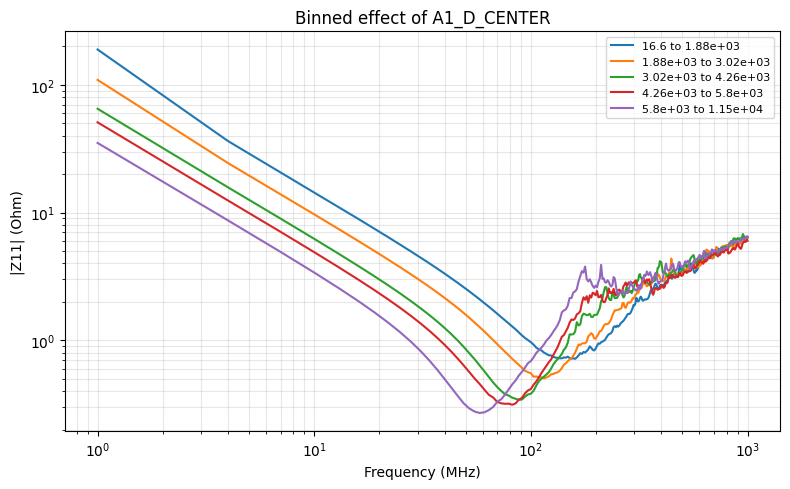

In [18]:
# Original raw-coordinate plots
plot_param_bins("A1_XCENTER")
plot_param_bins("A1_YCENTER")

# Better physical interpretation for A1 observation port
plot_param_bins("A1_D_NEAREST_EDGE")
plot_param_bins("A1_D_CENTER")

A1 nearest-edge samples:
SID=104290, A1_D_NEAREST_EDGE=99.240, A1_XCENTER=2650.000, A1_YCENTER=1700.000, XWIDTH=2749.240, YWIDTH=3658.930
SID=101091, A1_D_NEAREST_EDGE=99.430, A1_XCENTER=2900.000, A1_YCENTER=6650.000, XWIDTH=2999.430, YWIDTH=15052.300
SID=110809, A1_D_NEAREST_EDGE=99.550, A1_XCENTER=9300.000, A1_YCENTER=2500.000, XWIDTH=11345.800, YWIDTH=2599.550

A1 farthest-from-edge samples:
SID=107860, A1_D_NEAREST_EDGE=7800.000, A1_XCENTER=8350.000, A1_YCENTER=7800.000, XWIDTH=16486.800, YWIDTH=16086.400
SID=106073, A1_D_NEAREST_EDGE=7709.500, A1_XCENTER=9050.000, A1_YCENTER=7900.000, XWIDTH=16759.500, YWIDTH=16076.000
SID=102278, A1_D_NEAREST_EDGE=7665.900, A1_XCENTER=9850.000, A1_YCENTER=7900.000, XWIDTH=17515.900, YWIDTH=17023.400


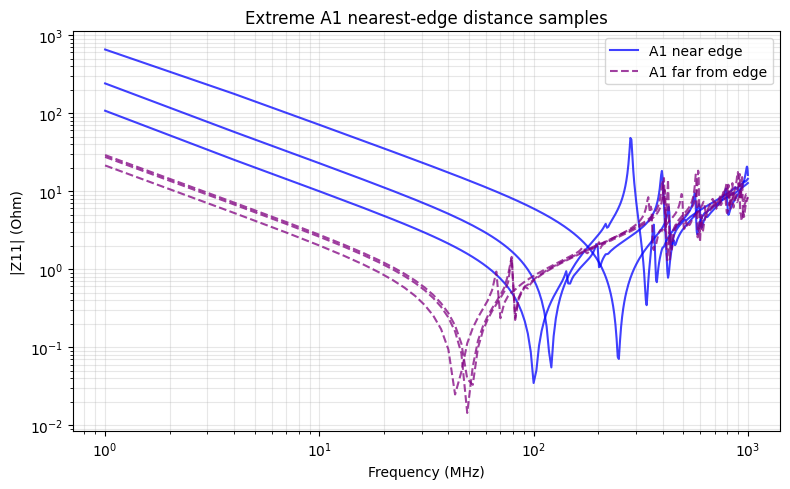

In [ ]:
# Plot 3 nearest-edge A1 samples vs 3 farthest-from-edge A1 samples
# A1 is considered the Z11 observation port

param = "A1_D_NEAREST_EDGE"
k = 3

if param not in db_df.columns:
    raise ValueError(f"{param} not found. Run the derived-feature setup cell first.")

# ----------------------------
# 1) Sort indices
# ----------------------------
values = db_df[param].values.astype(float)
valid_mask = np.isfinite(values)

valid_indices = np.where(valid_mask)[0]
sorted_valid_indices = valid_indices[np.argsort(values[valid_mask])]

near_edge_idx = sorted_valid_indices[:k]       # smallest distance to nearest edge
far_edge_idx  = sorted_valid_indices[-k:][::-1] # largest distance to nearest edge

# ----------------------------
# 2) Print Simu IDs and geometry info
# ----------------------------
print("A1 nearest-edge samples:")
for r in near_edge_idx:
    print(
        f"SID={int(db_df.iloc[r]['simu_index'])}, "
        f"A1_D_NEAREST_EDGE={db_df.iloc[r][param]:.3f}, "
        f"A1_XCENTER={db_df.iloc[r]['A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.iloc[r]['A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.iloc[r]['XWIDTH']:.3f}, "
        f"YWIDTH={db_df.iloc[r]['YWIDTH']:.3f}"
    )

print("\nA1 farthest-from-edge samples:")
for r in far_edge_idx:
    print(
        f"SID={int(db_df.iloc[r]['simu_index'])}, "
        f"A1_D_NEAREST_EDGE={db_df.iloc[r][param]:.3f}, "
        f"A1_XCENTER={db_df.iloc[r]['A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.iloc[r]['A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.iloc[r]['XWIDTH']:.3f}, "
        f"YWIDTH={db_df.iloc[r]['YWIDTH']:.3f}"
    )

# ----------------------------
# 3) Plot
# ----------------------------
plt.figure(figsize=(8, 5))

# --- nearest to edge
for i, r in enumerate(near_edge_idx):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="blue",
        alpha=0.75,
        linewidth=1.5,
        linestyle="-",
        label="A1 near edge" if i == 0 else "",
    )

# --- farthest from edge / more interior
for i, r in enumerate(far_edge_idx):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="purple",
        alpha=0.75,
        linewidth=1.5,
        linestyle="--",
        label="A1 far from edge" if i == 0 else "",
    )

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title("Extreme A1 nearest-edge distance samples")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Controlled board-size window:
XWIDTH: 10000 to 14000
YWIDTH: 10000 to 14000
Candidate samples: 1284

A1 near-edge samples within fixed board-size window:
SID=106793, A1_D_NEAREST_EDGE=99.800, A1_XCENTER=6450.000, A1_YCENTER=12750.000, XWIDTH=11977.300, YWIDTH=12849.800
SID=111833, A1_D_NEAREST_EDGE=102.200, A1_XCENTER=10400.000, A1_YCENTER=13450.000, XWIDTH=13229.100, YWIDTH=13552.200
SID=112628, A1_D_NEAREST_EDGE=107.000, A1_XCENTER=12800.000, A1_YCENTER=10400.000, XWIDTH=12907.000, YWIDTH=11266.000
SID=112635, A1_D_NEAREST_EDGE=107.700, A1_XCENTER=10250.000, A1_YCENTER=11750.000, XWIDTH=13658.200, YWIDTH=11857.700

A1 far-from-edge samples within fixed board-size window:
SID=115660, A1_D_NEAREST_EDGE=5886.200, A1_XCENTER=6900.000, A1_YCENTER=6100.000, XWIDTH=12786.200, YWIDTH=13064.700
SID=108309, A1_D_NEAREST_EDGE=5696.400, A1_XCENTER=6400.000, A1_YCENTER=7800.000, XWIDTH=12764.100, YWIDTH=13496.400
SID=116878, A1_D_NEAREST_EDGE=5650.000, A1_XCENTER=5650.000, A1_YCENTER=6650.000, XW

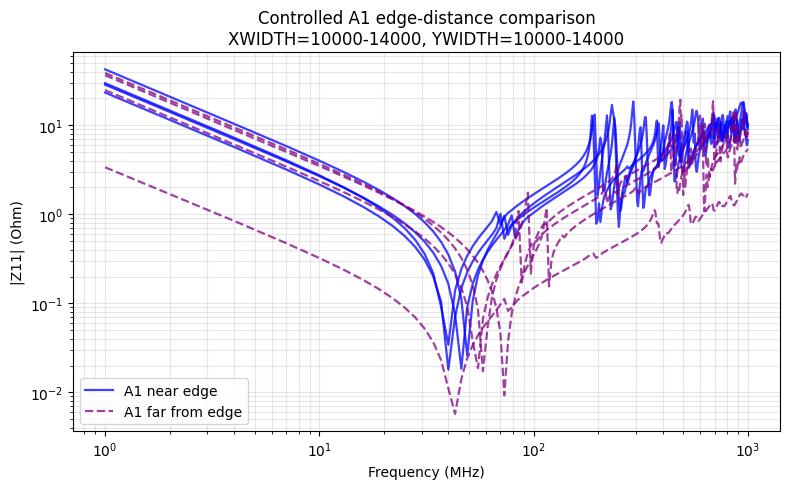

In [15]:
# Controlled edge-distance comparison:
# Keep board size approximately fixed, then compare A1 near-edge vs far-from-edge.

param = "A1_D_NEAREST_EDGE"
k = 4

# ----------------------------
# 1) Choose board-size window
# ----------------------------
x_min, x_max = 10000, 14000
y_min, y_max = 10000, 14000

if param not in db_df.columns:
    raise ValueError(f"{param} not found. Run the derived-feature setup cell first.")

size_mask = (
    (db_df["XWIDTH"] >= x_min) & (db_df["XWIDTH"] <= x_max) &
    (db_df["YWIDTH"] >= y_min) & (db_df["YWIDTH"] <= y_max)
)

candidate_df = db_df[size_mask].copy()

print("Controlled board-size window:")
print(f"XWIDTH: {x_min} to {x_max}")
print(f"YWIDTH: {y_min} to {y_max}")
print("Candidate samples:", len(candidate_df))

if len(candidate_df) < 2 * k:
    raise ValueError(
        f"Not enough samples in this board-size window. "
        f"Need at least {2*k}, got {len(candidate_df)}. "
        f"Try widening x/y range."
    )

# ----------------------------
# 2) Sort candidates by A1_D_NEAREST_EDGE
# ----------------------------
candidate_df = candidate_df.sort_values(param)

near_edge_rows = candidate_df.head(k).index.to_numpy()
far_edge_rows = candidate_df.tail(k).index.to_numpy()[::-1]

# ----------------------------
# 3) Print selected samples
# ----------------------------
print("\nA1 near-edge samples within fixed board-size window:")
for r in near_edge_rows:
    print(
        f"SID={int(db_df.loc[r, 'simu_index'])}, "
        f"{param}={db_df.loc[r, param]:.3f}, "
        f"A1_XCENTER={db_df.loc[r, 'A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.loc[r, 'A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.loc[r, 'XWIDTH']:.3f}, "
        f"YWIDTH={db_df.loc[r, 'YWIDTH']:.3f}"
    )

print("\nA1 far-from-edge samples within fixed board-size window:")
for r in far_edge_rows:
    print(
        f"SID={int(db_df.loc[r, 'simu_index'])}, "
        f"{param}={db_df.loc[r, param]:.3f}, "
        f"A1_XCENTER={db_df.loc[r, 'A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.loc[r, 'A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.loc[r, 'XWIDTH']:.3f}, "
        f"YWIDTH={db_df.loc[r, 'YWIDTH']:.3f}"
    )

# ----------------------------
# 4) Plot individual curves
# ----------------------------
plt.figure(figsize=(8, 5))

for i, r in enumerate(near_edge_rows):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="blue",
        linestyle="-",
        linewidth=1.6,
        alpha=0.75,
        label="A1 near edge" if i == 0 else "",
    )

for i, r in enumerate(far_edge_rows):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="purple",
        linestyle="--",
        linewidth=1.6,
        alpha=0.75,
        label="A1 far from edge" if i == 0 else "",
    )

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title(
    "Controlled A1 edge-distance comparison\n"
    f"XWIDTH={x_min}-{x_max}, YWIDTH={y_min}-{y_max}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

When A1 is farther from the edge:
- the port is more interior
- current can spread more symmetrically
- The impedance is lower and the response is smoother the first resonance region shifts

When A1 is close to an edge:
- current spreading is constrained by the nearby boundary
- modal coupling is stronger or more irregular
- sharp peaks appear in the resonance/high-frequency region

Controlled board-size window:
XWIDTH: 10000 to 14000
YWIDTH: 10000 to 14000
Candidate samples: 1284

A1 near-center samples within fixed board-size window:
SID=106114, A1_D_CENTER=236.163, A1_DX_CENTER=205.400, A1_DY_CENTER=116.550, A1_XCENTER=5350.000, A1_YCENTER=5550.000, XWIDTH=11110.800, YWIDTH=10866.900
SID=106540, A1_D_CENTER=236.422, A1_DX_CENTER=47.750, A1_DY_CENTER=231.550, A1_XCENTER=5050.000, A1_YCENTER=5700.000, XWIDTH=10004.500, YWIDTH=11863.100
SID=104691, A1_D_CENTER=270.839, A1_DX_CENTER=212.200, A1_DY_CENTER=168.300, A1_XCENTER=5950.000, A1_YCENTER=5250.000, XWIDTH=12324.400, YWIDTH=10163.400
SID=114622, A1_D_CENTER=392.140, A1_DX_CENTER=125.100, A1_DY_CENTER=371.650, A1_XCENTER=5300.000, A1_YCENTER=5400.000, XWIDTH=10349.800, YWIDTH=10056.700
SID=100558, A1_D_CENTER=396.372, A1_DX_CENTER=48.450, A1_DY_CENTER=393.400, A1_XCENTER=6450.000, A1_YCENTER=5350.000, XWIDTH=12996.900, YWIDTH=11486.800

A1 far-from-center samples within fixed board-size window:
SID=119816, A1_D

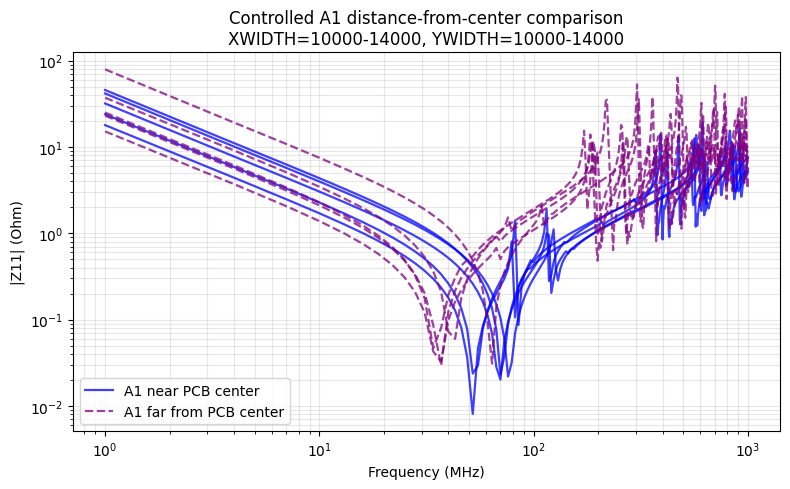

In [17]:
# Controlled center-distance comparison:
# Keep board size approximately fixed, then compare A1 near-center vs far-from-center.

param = "A1_D_CENTER"
k = 5

# ----------------------------
# 1) Choose board-size window
# ----------------------------
x_min, x_max = 10000, 14000
y_min, y_max = 10000, 14000

if param not in db_df.columns:
    raise ValueError(f"{param} not found. Run the derived-feature setup cell first.")

size_mask = (
    (db_df["XWIDTH"] >= x_min) & (db_df["XWIDTH"] <= x_max) &
    (db_df["YWIDTH"] >= y_min) & (db_df["YWIDTH"] <= y_max)
)

candidate_df = db_df[size_mask].copy()

print("Controlled board-size window:")
print(f"XWIDTH: {x_min} to {x_max}")
print(f"YWIDTH: {y_min} to {y_max}")
print("Candidate samples:", len(candidate_df))

if len(candidate_df) < 2 * k:
    raise ValueError(
        f"Not enough samples in this board-size window. "
        f"Need at least {2*k}, got {len(candidate_df)}. "
        f"Try widening x/y range."
    )

# ----------------------------
# 2) Sort candidates by A1_D_CENTER
# ----------------------------
candidate_df = candidate_df.sort_values(param)

near_center_rows = candidate_df.head(k).index.to_numpy()         # close to PCB center
far_center_rows  = candidate_df.tail(k).index.to_numpy()[::-1]   # far from PCB center

# ----------------------------
# 3) Print selected samples
# ----------------------------
print("\nA1 near-center samples within fixed board-size window:")
for r in near_center_rows:
    print(
        f"SID={int(db_df.loc[r, 'simu_index'])}, "
        f"{param}={db_df.loc[r, param]:.3f}, "
        f"A1_DX_CENTER={db_df.loc[r, 'A1_DX_CENTER']:.3f}, "
        f"A1_DY_CENTER={db_df.loc[r, 'A1_DY_CENTER']:.3f}, "
        f"A1_XCENTER={db_df.loc[r, 'A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.loc[r, 'A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.loc[r, 'XWIDTH']:.3f}, "
        f"YWIDTH={db_df.loc[r, 'YWIDTH']:.3f}"
    )

print("\nA1 far-from-center samples within fixed board-size window:")
for r in far_center_rows:
    print(
        f"SID={int(db_df.loc[r, 'simu_index'])}, "
        f"{param}={db_df.loc[r, param]:.3f}, "
        f"A1_DX_CENTER={db_df.loc[r, 'A1_DX_CENTER']:.3f}, "
        f"A1_DY_CENTER={db_df.loc[r, 'A1_DY_CENTER']:.3f}, "
        f"A1_XCENTER={db_df.loc[r, 'A1_XCENTER']:.3f}, "
        f"A1_YCENTER={db_df.loc[r, 'A1_YCENTER']:.3f}, "
        f"XWIDTH={db_df.loc[r, 'XWIDTH']:.3f}, "
        f"YWIDTH={db_df.loc[r, 'YWIDTH']:.3f}"
    )

# ----------------------------
# 4) Plot individual curves
# ----------------------------
plt.figure(figsize=(8, 5))

for i, r in enumerate(near_center_rows):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="blue",
        linestyle="-",
        linewidth=1.6,
        alpha=0.75,
        label="A1 near PCB center" if i == 0 else "",
    )

for i, r in enumerate(far_center_rows):
    x = ds_full.impedance_data[r].cpu().numpy()
    mag = np.exp(x[0, :])

    plt.loglog(
        freq_mhz,
        mag,
        color="purple",
        linestyle="--",
        linewidth=1.6,
        alpha=0.75,
        label="A1 far from PCB center" if i == 0 else "",
    )

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title(
    "Controlled A1 distance-from-center comparison\n"
    f"XWIDTH={x_min}-{x_max}, YWIDTH={y_min}-{y_max}"
)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

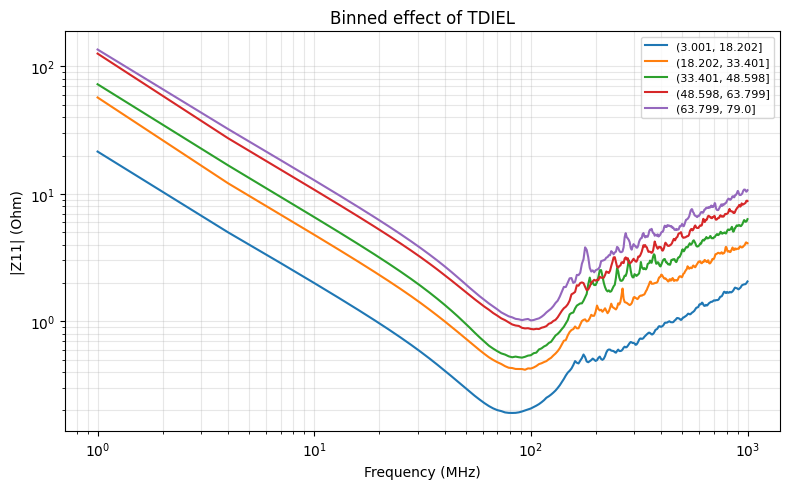

In [62]:
plot_param_bins("TDIEL")

In [70]:
db_df['TDIEL'].describe()

count    20000.000000
mean        40.999993
std         21.939848
min          3.001920
25%         22.000500
50%         40.999800
75%         60.000075
max         78.999700
Name: TDIEL, dtype: float64

Low TDIEL samples:
SID=114254, TDIEL=3.002
SID=119590, TDIEL=3.006
SID=108318, TDIEL=3.011
SID=105290, TDIEL=3.013
SID=103844, TDIEL=3.015

High TDIEL samples:
SID=107305, TDIEL=78.981
SID=111204, TDIEL=78.987
SID=103495, TDIEL=78.991
SID=112733, TDIEL=78.996
SID=114421, TDIEL=79.000


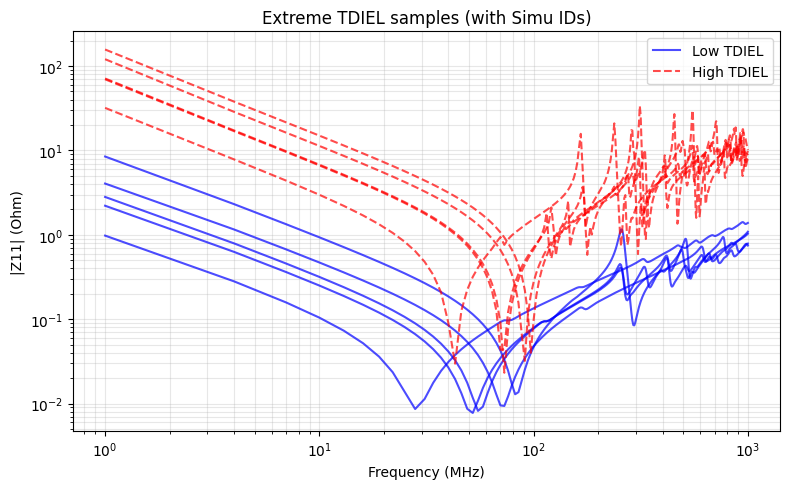

In [72]:
# Plot 5 lowest TDIEL vs 5 highest TDIEL samples (WITH SIMU IDs)

param = "TDIEL"
k = 5

# ----------------------------
# 1) Sort indices
# ----------------------------
sorted_idx = np.argsort(db_df[param].values)

low_idx = sorted_idx[:k]
high_idx = sorted_idx[-k:]

# ----------------------------
# 2) Extract Simu IDs
# ----------------------------
low_sids = db_df.iloc[low_idx]["simu_index"].values
high_sids = db_df.iloc[high_idx]["simu_index"].values

print("Low TDIEL samples:")
for sid, val in zip(low_sids, db_df.iloc[low_idx][param].values):
   print(f"SID={sid}, TDIEL={val:.3f}")

print("\nHigh TDIEL samples:")
for sid, val in zip(high_sids, db_df.iloc[high_idx][param].values):
   print(f"SID={sid}, TDIEL={val:.3f}")

# ----------------------------
# 3) Plot
# ----------------------------
plt.figure(figsize=(8, 5))

# --- LOW TDIEL
for i, r in enumerate(low_idx):
   x = ds_full.impedance_data[r].cpu().numpy()
   mag = np.exp(x[0, :])
   sid = db_df.iloc[r]["simu_index"]

   plt.loglog(freq_mhz, mag, color="blue", alpha=0.7,
              label="Low TDIEL" if i == 0 else "",
              linestyle="-")

# --- HIGH TDIEL
for i, r in enumerate(high_idx):
   x = ds_full.impedance_data[r].cpu().numpy()
   mag = np.exp(x[0, :])
   sid = db_df.iloc[r]["simu_index"]

   plt.loglog(freq_mhz, mag, color="red", alpha=0.7,
              label="High TDIEL" if i == 0 else "",
              linestyle="--")

plt.xlabel("Frequency (MHz)")
plt.ylabel("|Z11| (Ohm)")
plt.title("Extreme TDIEL samples (with Simu IDs)")
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

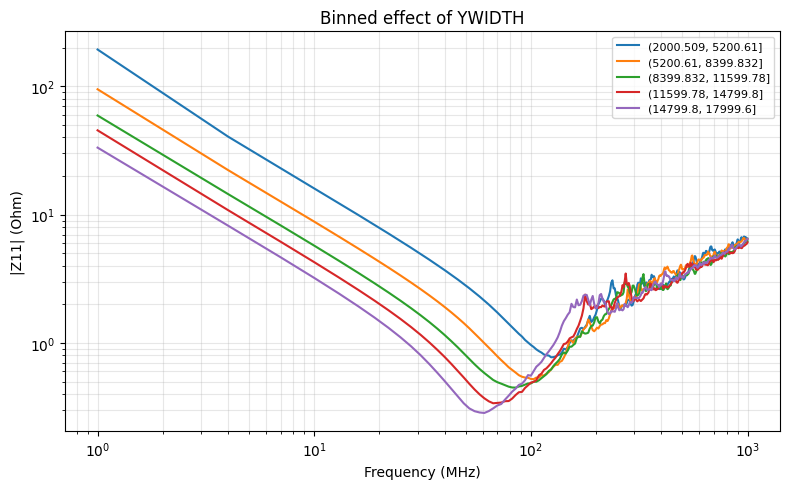

In [68]:
plot_param_bins("YWIDTH")

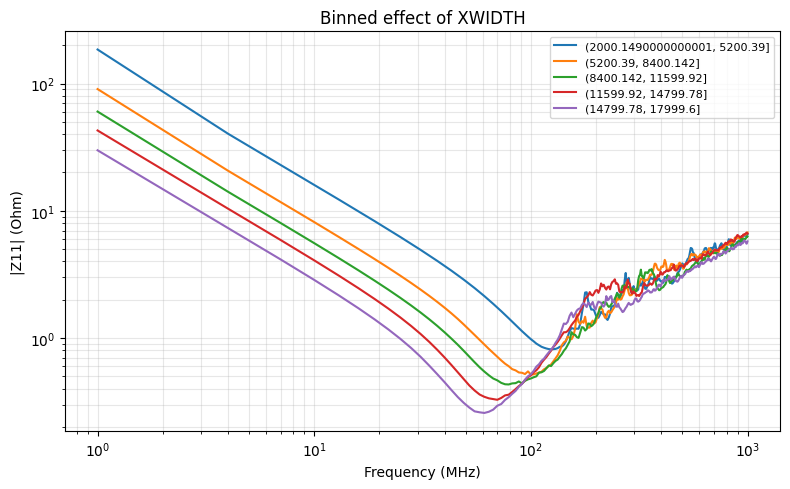

In [69]:
plot_param_bins("XWIDTH")